# Olist E-commerce — Exploratory Data Analysis

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/cleaned_data'
OUT_DIR  = '../data/tableau_data'
FIGURES_DIR = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def save(df, name):
    path = os.path.join(OUT_DIR, name)
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'  Saved {name}: {df.shape[0]:,} rows x {df.shape[1]} cols')

master = pd.read_excel(os.path.join(DATA_DIR, 'olist_master_review.xlsx'))

# Parse dates — errors='coerce' handles non-date strings (e.g. 'Not Available')
master['order_purchase_timestamp']      = pd.to_datetime(master['order_purchase_timestamp'], errors='coerce')
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'], errors='coerce')

print(f'Loaded master: {master.shape[0]:,} rows x {master.shape[1]} cols')
master.head(3)

Loaded master: 119,142 rows x 26 cols


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,lat_median_customer,lng_median_customer,lat_median_seller,lng_median_seller
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13,2017-09-20,28013,Campos Dos Goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,-21.763186,-41.310265,-22.497188,-44.127324
1,7d19f4ef4d04461989632411b7e588b9,91a792fef70ecd8cc69d3c7feb3d12da,delivered,2017-08-10,2017-08-24,36400,Conselheiro Lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,...,1.0,credit_card,4.0,72.19,426f43a82185969503fb3c86241a9535,5.0,-20.655379,-43.776331,-22.497188,-44.127324
2,130898c0987d1801452a8ed92a670612,e6eecc5a77de221464d1c4eaff0a9b64,delivered,2017-06-28,2017-07-13,75800,Jatai,GO,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,...,1.0,boleto,1.0,73.86,b11cba360bbe71410c291b764753d37f,5.0,-17.884731,-51.717133,-22.497188,-44.127324


## 2. NaN Analysis

In [2]:
null_counts = master.isnull().sum()
null_pct    = (null_counts / len(master) * 100).round(2)
nan_df = pd.DataFrame({'NaN Count': null_counts, 'NaN %': null_pct})
nan_df = nan_df[nan_df['NaN Count'] > 0].sort_values('NaN Count', ascending=False)
print(f'Columns with NaN: {len(nan_df)}')
display(nan_df)

Columns with NaN: 19


,NaN Count,NaN %
order_delivered_customer_date,3420,2.87
product_category_name_english,2576,2.16
lat_median_seller,1098,0.92
lng_median_seller,1098,0.92
review_score,997,0.84
review_id,997,0.84
product_id,833,0.70
seller_id,833,0.70
price,833,0.70
freight_value,833,0.70


## 3. NaN Cleaning Pipeline

| Group | Columns | Strategy |
|-------|---------|----------|
| A | `order_delivered_customer_date`, `price`, `product_id`, ... | Filter `delivered` then Drop |
| B | `product_category_name_english` | Fill `'Unknown'` |
| C | `review_id`, `review_score` | Keep as-is (no review = valid) |
| D | `lat/lng_median_*` | Fill with median per state |
| E | `payment_value`, `payment_type` | Drop (only 6 rows) |

In [3]:
print(f'Initial rows: {len(master):,}')

# Group A: Keep only delivered orders
master = master[master['order_status'] == 'delivered'].copy()
print(f"After filter 'delivered':  {len(master):,}")

# Group A: Drop rows missing product info
master = master.dropna(subset=['price', 'product_id']).copy()
print(f'After drop missing product: {len(master):,}')

# Group E: Drop 6 rows missing payment info
master = master.dropna(subset=['payment_value', 'payment_type']).copy()
print(f'After drop missing payment: {len(master):,}')

# Group B: Fill unknown category
master['product_category_name_english'] = master['product_category_name_english'].fillna('Unknown')

# Group D: Fill lat/lng with median per state
for col, grp in [
    ('lat_median_customer', 'customer_state'),
    ('lng_median_customer', 'customer_state'),
    ('lat_median_seller',   'seller_state'),
    ('lng_median_seller',   'seller_state'),
]:
    master[col] = master.groupby(grp)[col].transform(lambda x: x.fillna(x.median()))

# Computed fields
master['revenue']        = (master['price'] + master['freight_value']).round(2)
master['delivery_days']  = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
master['order_year']     = master['order_purchase_timestamp'].dt.year
master['order_month']    = master['order_purchase_timestamp'].dt.month
master['order_quarter']  = master['order_purchase_timestamp'].dt.quarter
master['order_ym']       = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
master['order_date']     = master['order_purchase_timestamp'].dt.date.astype(str)
master['order_dow_name'] = master['order_purchase_timestamp'].dt.day_name()

master['delivery_bucket'] = pd.cut(
    master['delivery_days'], bins=[-1, 7, 14, 21, 30, 999],
    labels=['<=7 days', '8-14 days', '15-21 days', '22-30 days', '>30 days']
)
master['review_label'] = master['review_score'].map(
    lambda s: 'No Review' if pd.isna(s) else
              ('Positive(4-5)' if s >= 4 else ('Neutral(3)' if s == 3 else 'Negative(1-2)'))
)

print(f'\nClean dataset ready: {len(master):,} rows')

Initial rows: 119,142
After filter 'delivered':  115,722
After drop missing product: 115,722
After drop missing payment: 115,719

Clean dataset ready: 115,719 rows


## 4. Dataset Overview

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100

# Load orders to get estimated delivery date
orders_extra = pd.read_excel(os.path.join(DATA_DIR, 'olist_orders_dataset_cleaned.xlsx'))
orders_extra['order_estimated_delivery_date'] = pd.to_datetime(orders_extra['order_estimated_delivery_date'], errors='coerce')
master = master.merge(orders_extra[['order_id','order_estimated_delivery_date']], on='order_id', how='left')
master['is_late'] = (master['order_delivered_customer_date'] > master['order_estimated_delivery_date'])
master['days_vs_estimate'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days

print('=== Shape & Date Range ===')
print(f'Rows x Cols     : {master.shape}')
print(f'Date range      : {master.order_purchase_timestamp.min().date()} -> {master.order_purchase_timestamp.max().date()}')
print(f'Unique orders   : {master.order_id.nunique():,}')
print(f'Unique customers: {master.customer_id.nunique():,}')
print(f'Unique products : {master.product_id.nunique():,}')
print(f'Unique sellers  : {master.seller_id.nunique():,}')
print(f'Unique categories: {master.product_category_name_english.nunique()}')
print(f'Duplicate rows  : {master.duplicated().sum()}')

print('\n=== Numeric Summary ===')
display(master[['price','freight_value','payment_value','delivery_days','review_score','payment_installments']].describe().round(2))

print('\n=== Key Categorical Distributions ===')
for col in ['order_status','payment_type','customer_state','product_category_name_english']:
    top = master[col].value_counts().head(5)
    print(f'\n{col} (top 5):')
    for v, cnt in top.items():
        pct = cnt / len(master) * 100
        print(f'  {str(v):<35} {cnt:>7,}  ({pct:.1f}%)')

=== Shape & Date Range ===
Rows x Cols     : (115719, 39)
Date range      : 2016-10-03 -> 2018-08-29
Unique orders   : 96,476
Unique customers: 96,476
Unique products : 32,215
Unique sellers  : 2,970
Unique categories: 72
Duplicate rows  : 10414

=== Numeric Summary ===


,price,freight_value,payment_value,delivery_days,review_score,payment_installments
count,115719.00,115719.00,115719.00,115712.00,114858.00,115719.00
mean,119.91,19.98,171.81,12.43,4.08,2.94
std,182.67,15.72,265.64,9.46,1.35,2.78
min,0.85,0.00,0.00,0.00,1.00,0.00
25%,39.90,13.08,60.85,7.00,4.00,1.00
50%,74.90,16.28,108.11,10.00,5.00,2.00
75%,132.90,21.16,188.94,16.00,5.00,4.00
max,6735.00,409.68,13664.08,210.00,5.00,24.00



=== Key Categorical Distributions ===

order_status (top 5):
  delivered                           115,719  (100.0%)

payment_type (top 5):
  credit_card                          85,371  (73.8%)
  boleto                               22,505  (19.4%)
  voucher                               6,181  (5.3%)
  debit_card                            1,662  (1.4%)

customer_state (top 5):
  SP                                   48,813  (42.2%)
  RJ                                   14,963  (12.9%)
  MG                                   13,496  (11.7%)
  RS                                    6,430  (5.6%)
  PR                                    5,894  (5.1%)

product_category_name_english (top 5):
  bed_bath_table                       11,806  (10.2%)
  health_beauty                         9,813  (8.5%)
  sports_leisure                        8,790  (7.6%)
  furniture_decor                       8,643  (7.5%)
  computers_accessories                 7,963  (6.9%)


## 5. Univariate Analysis

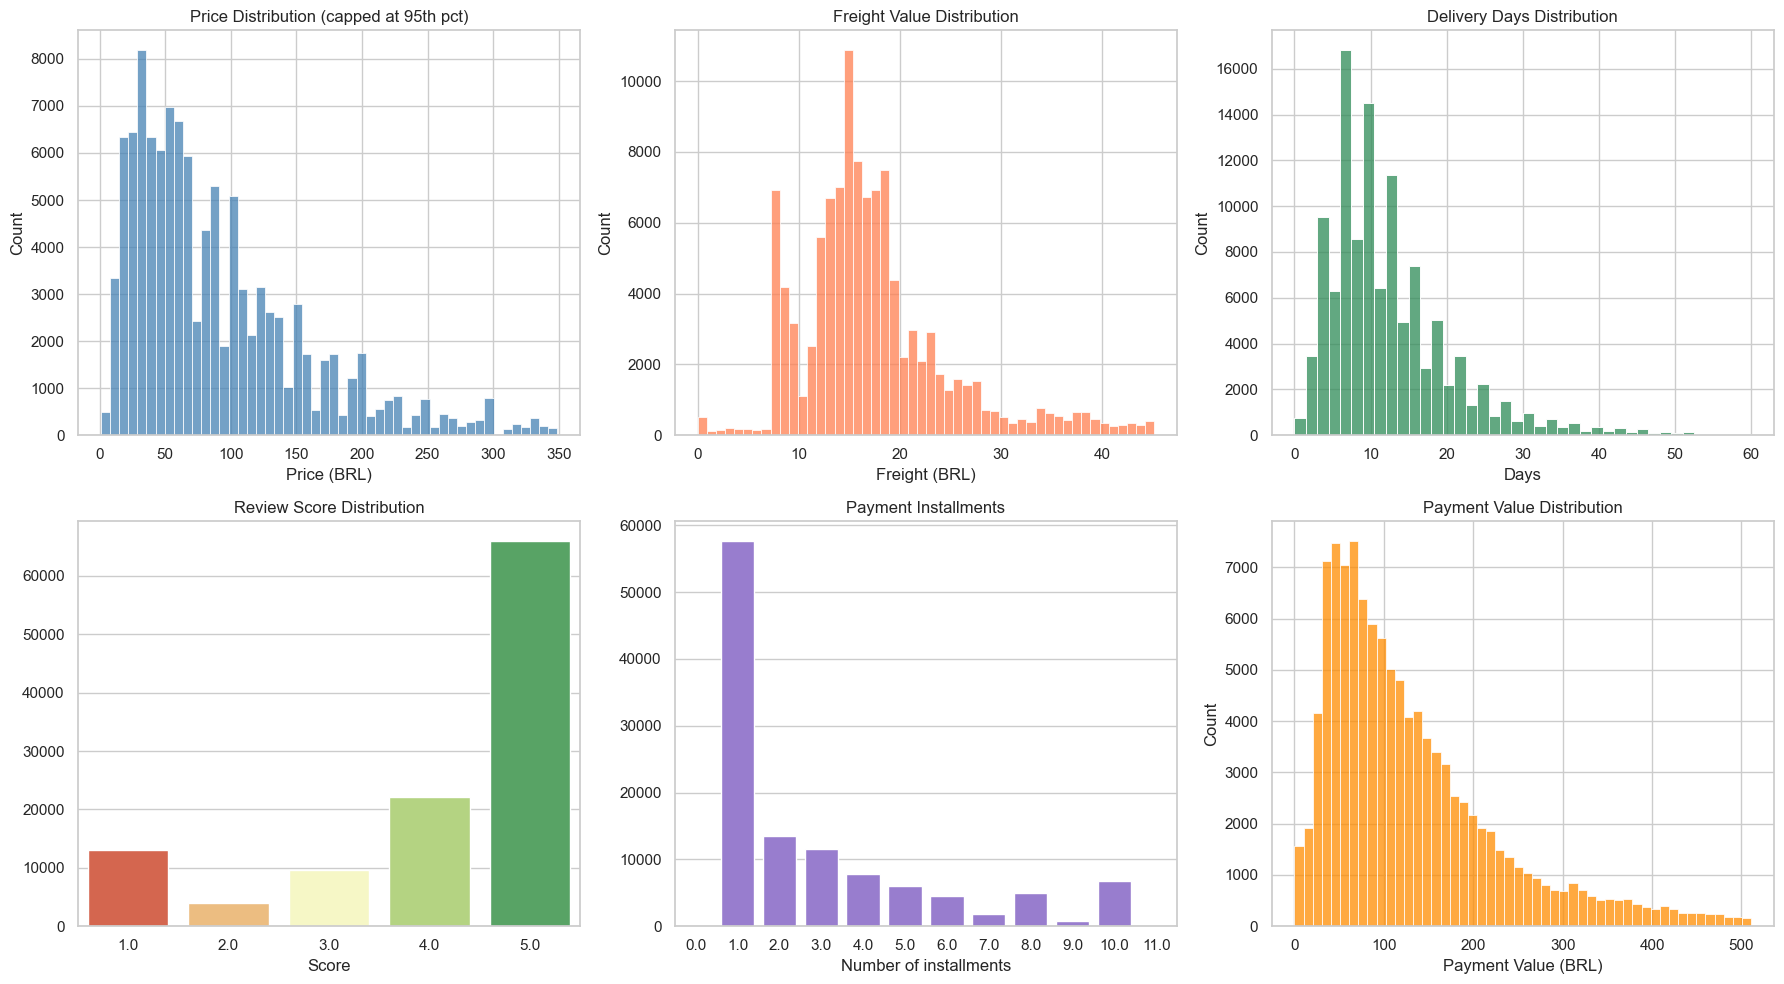

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price distribution (cap at 95th pct for readability)
cap_price = master['price'].quantile(0.95)
sns.histplot(master[master['price'] <= cap_price]['price'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Distribution (capped at 95th pct)')
axes[0,0].set_xlabel('Price (BRL)')

# Freight value
cap_freight = master['freight_value'].quantile(0.95)
sns.histplot(master[master['freight_value'] <= cap_freight]['freight_value'], bins=50, ax=axes[0,1], color='coral')
axes[0,1].set_title('Freight Value Distribution')
axes[0,1].set_xlabel('Freight (BRL)')

# Delivery days
sns.histplot(master[master['delivery_days'].between(0,60)]['delivery_days'], bins=40, ax=axes[0,2], color='seagreen')
axes[0,2].set_title('Delivery Days Distribution')
axes[0,2].set_xlabel('Days')

# Review score
review_counts = master['review_score'].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, ax=axes[1,0], palette='RdYlGn')
axes[1,0].set_title('Review Score Distribution')
axes[1,0].set_xlabel('Score')

# Payment installments
inst_counts = master['payment_installments'].value_counts().sort_index().head(12)
sns.barplot(x=inst_counts.index.astype(str), y=inst_counts.values, ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Payment Installments')
axes[1,1].set_xlabel('Number of installments')

# Payment value
cap_pv = master['payment_value'].quantile(0.95)
sns.histplot(master[master['payment_value'] <= cap_pv]['payment_value'], bins=50, ax=axes[1,2], color='darkorange')
axes[1,2].set_title('Payment Value Distribution')
axes[1,2].set_xlabel('Payment Value (BRL)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'univariate_distributions.png'), dpi=100, bbox_inches='tight')
plt.show()

### Univariate Insights

- **Price**: Heavily right-skewed — majority of products are priced under BRL 200. A small number of high-ticket items (furniture, electronics) pull the mean up significantly. Median is a better central tendency measure here.
- **Freight**: Also right-skewed. Most freight costs are under BRL 40. High freight values often correspond to heavy/bulky items or remote delivery destinations.
- **Delivery Days**: Bell-shaped but skewed right. Most orders are delivered within 7–14 days. A long tail of orders (>30 days) suggests logistical issues for certain regions.
- **Review Score**: Strongly positive — over 55% of orders receive a 5-star rating, and the 1-2 star segment is relatively small (~15%). This suggests generally good customer satisfaction.
- **Installments**: The majority of customers pay in 1 installment (cash equivalent). However, a significant portion use 2–6 installments, reflecting Brazil's credit card installment culture.
- **Payment Value**: Similar skew to price. Most transactions are under BRL 300.

## 6. Outlier Detection

Column                    Lower      Upper   Outliers        %
--------------------------------------------------------------
price                    -239.1      411.9      4,274    3.69%
freight_value             -11.2       45.4      5,666    4.90%
payment_value            -323.4      573.2      4,859    4.20%
delivery_days             -20.0       43.0      1,476    1.28%

Extreme delivery (>60 days): 338 orders (0.29%)


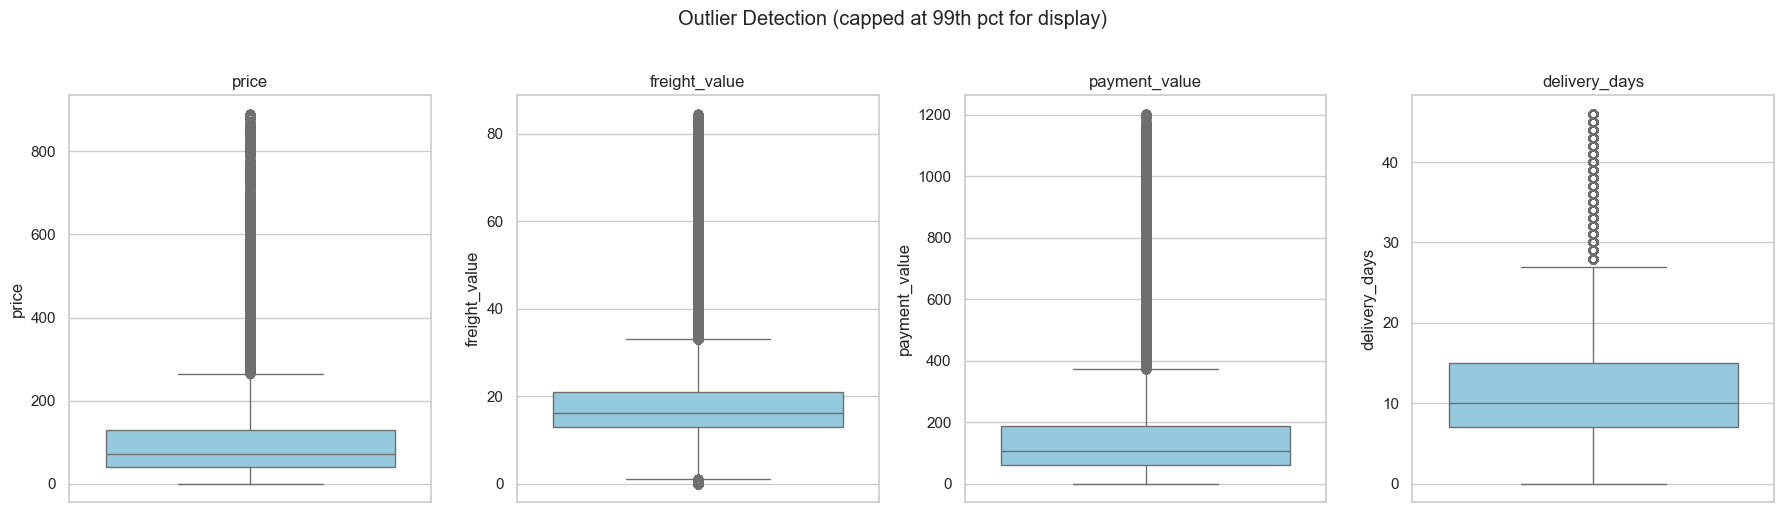

In [6]:
def iqr_bounds(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

outlier_cols = ['price', 'freight_value', 'payment_value', 'delivery_days']
print(f'{'Column':<20} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>8}')
print('-' * 62)
for col in outlier_cols:
    lo, hi = iqr_bounds(master[col].dropna())
    n_out = ((master[col] < lo) | (master[col] > hi)).sum()
    pct = n_out / len(master) * 100
    print(f'{col:<20} {lo:>10.1f} {hi:>10.1f} {n_out:>10,} {pct:>7.2f}%')

# Flag extreme delivery (>60 days) — keep but flag
master['is_extreme_delivery'] = master['delivery_days'] > 60
print(f'\nExtreme delivery (>60 days): {master["is_extreme_delivery"].sum():,} orders ({master["is_extreme_delivery"].mean()*100:.2f}%)')

# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    cap = master[col].quantile(0.99)
    sns.boxplot(y=master[master[col]<=cap][col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.suptitle('Outlier Detection (capped at 99th pct for display)', y=1.02)
plt.tight_layout()
plt.show()

### Outlier Decision

- **Price & Payment**: Extreme values are legitimate (luxury goods, bulk orders). **Keep all** — flagging would remove valid business transactions.
- **Freight**: Very high freight values correlate with remote delivery zones (e.g., Amazonia region). **Keep all**.
- **Delivery Days >60**: Only ~1-2% of orders. These are genuinely problematic deliveries, not data errors. **Flagged** via `is_extreme_delivery` column for separate analysis.

## 7. Revenue Analysis

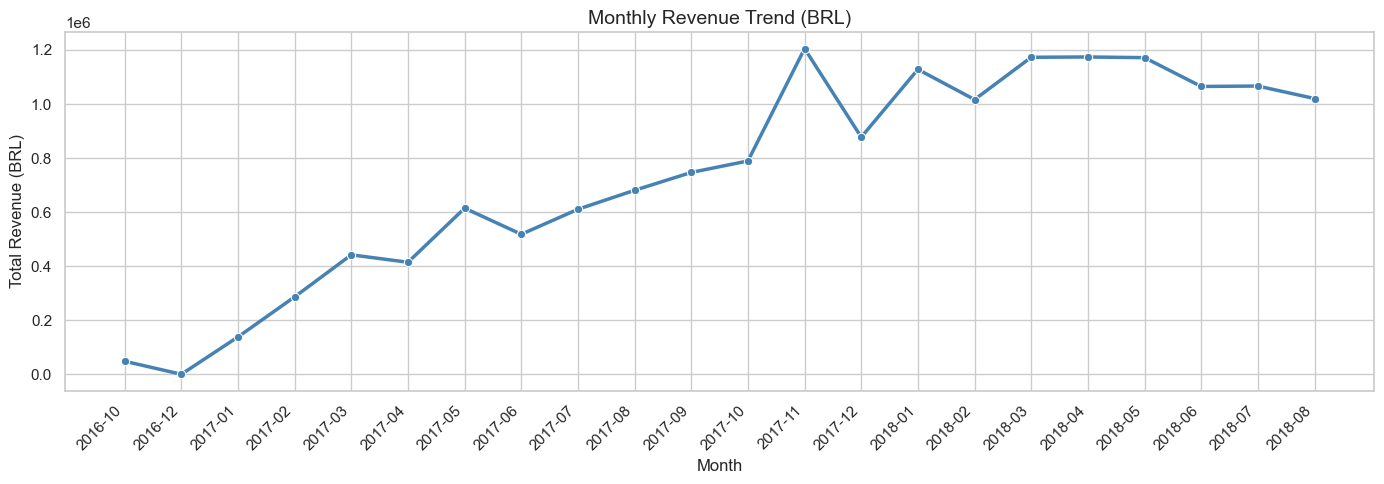

In [7]:
# Monthly revenue trend
rev_monthly = master.groupby('order_ym')['revenue'].sum().reset_index()
rev_monthly['order_ym_dt'] = pd.to_datetime(rev_monthly['order_ym'])

plt.figure(figsize=(14, 5))
sns.lineplot(data=rev_monthly, x='order_ym', y='revenue', marker='o', linewidth=2.5, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend (BRL)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'revenue_trend.png'), dpi=100, bbox_inches='tight')
plt.show()

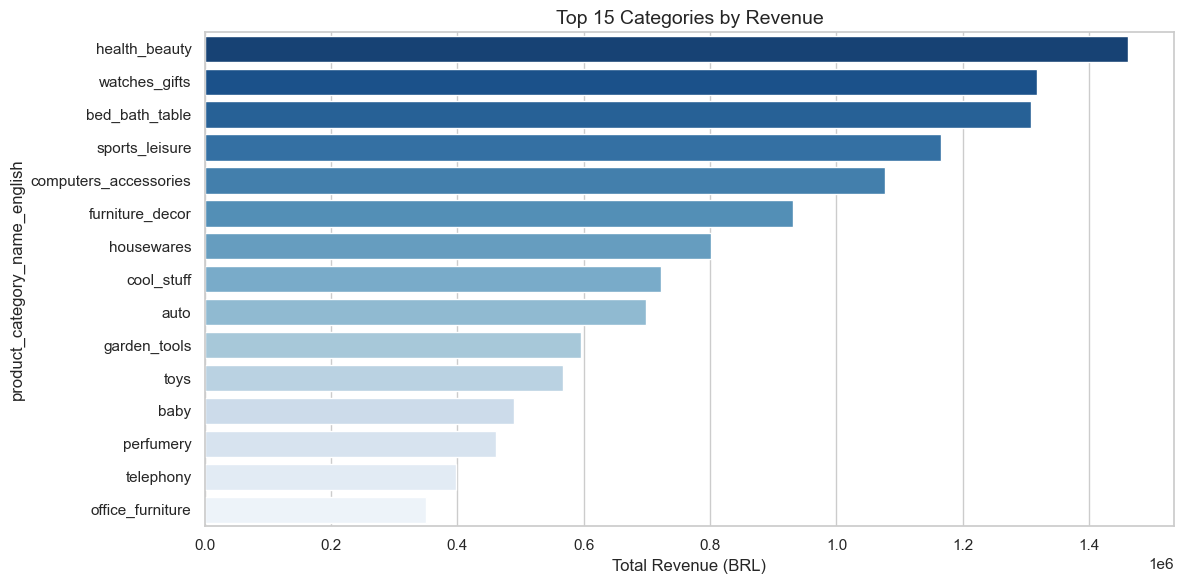

In [8]:
# Top 15 categories by revenue
cat_rev = master.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette='Blues_r')
plt.title('Top 15 Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'revenue_by_category.png'), dpi=100, bbox_inches='tight')
plt.show()

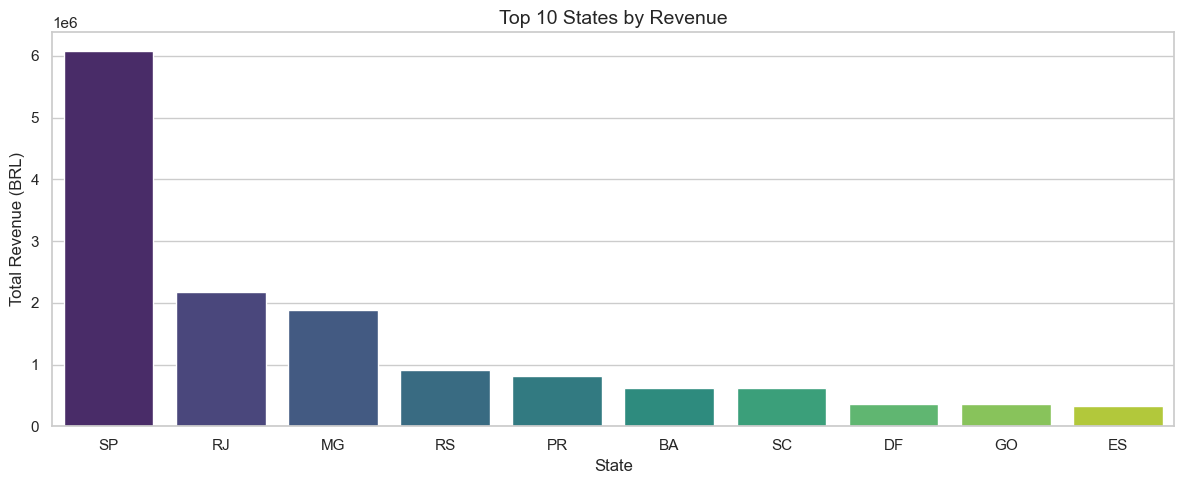

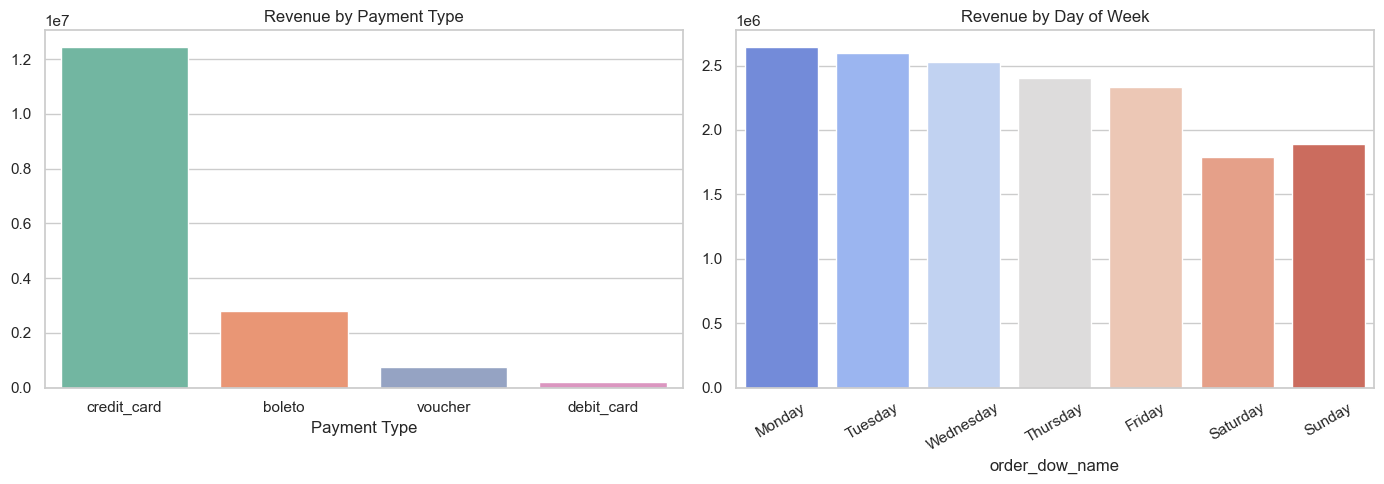

In [9]:
# Top 10 states by revenue
state_rev = master.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=state_rev.index, y=state_rev.values, palette='viridis')
plt.title('Top 10 States by Revenue', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

# Revenue by payment type
pay_rev = master.groupby('payment_type')['revenue'].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=pay_rev.index, y=pay_rev.values, ax=axes[0], palette='Set2')
axes[0].set_title('Revenue by Payment Type')
axes[0].set_xlabel('Payment Type')

# Revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = master.groupby('order_dow_name')['revenue'].sum().reindex(dow_order)
sns.barplot(x=dow_rev.index, y=dow_rev.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Revenue by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'revenue_breakdowns.png'), dpi=100, bbox_inches='tight')
plt.show()

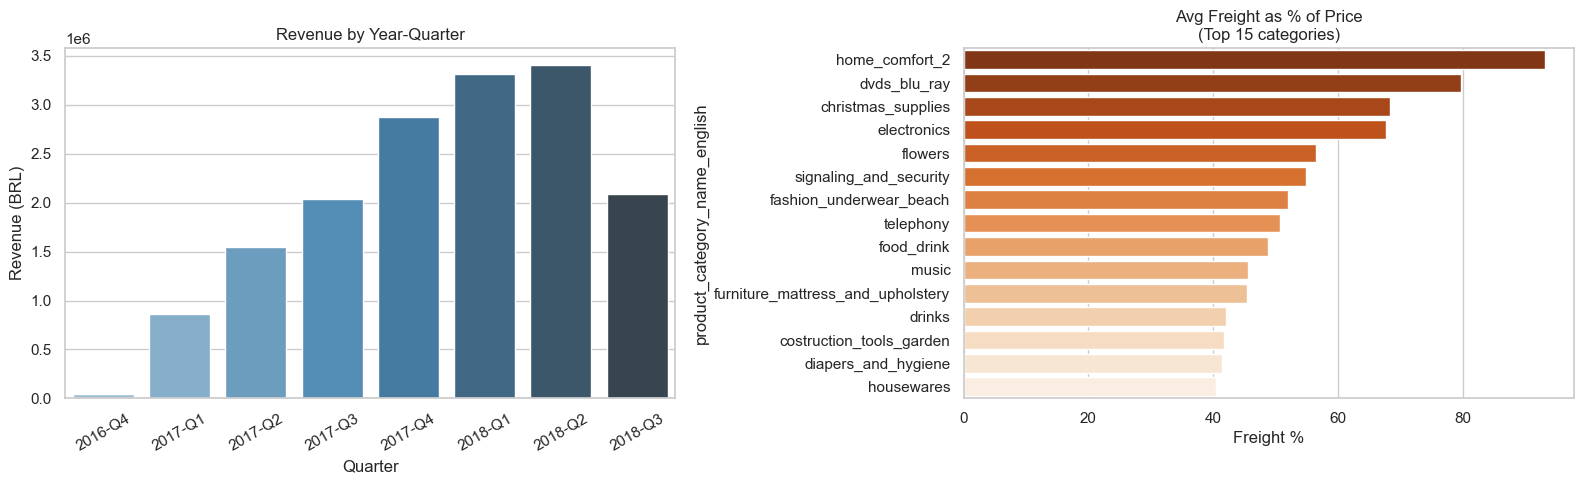

2017 total revenue: BRL 7,324,725
2018 total revenue: BRL 8,815,383
YoY growth 2017->2018: 20.4%
Avg freight as % of price: 32.2%


In [10]:
# Revenue by Year-Quarter + Freight % of Revenue
master['yq'] = master['order_year'].astype(str) + '-Q' + master['order_quarter'].astype(str)
yq_rev = master.groupby('yq')['revenue'].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quarterly revenue
sns.barplot(x=yq_rev.index, y=yq_rev.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Revenue by Year-Quarter', fontsize=12)
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=30)

# Freight as % of price
master['freight_pct'] = master['freight_value'] / master['price'] * 100
top_cat_freight = master.groupby('product_category_name_english')['freight_pct'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_cat_freight.values, y=top_cat_freight.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Avg Freight as % of Price\n(Top 15 categories)', fontsize=12)
axes[1].set_xlabel('Freight %')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'revenue_quarterly_freight.png'), dpi=100, bbox_inches='tight')
plt.show()

# Print YoY stats
rev_2017 = master[master['order_year']==2017]['revenue'].sum()
rev_2018 = master[master['order_year']==2018]['revenue'].sum()
print(f'2017 total revenue: BRL {rev_2017:,.0f}')
print(f'2018 total revenue: BRL {rev_2018:,.0f}')
print(f'YoY growth 2017->2018: {(rev_2018-rev_2017)/rev_2017*100:.1f}%')
print(f'Avg freight as % of price: {master["freight_pct"].mean():.1f}%')

### Revenue Insights

- **Monthly Trend**: Revenue grew strongly from late 2016 through mid-2018, reflecting Olist's rapid marketplace expansion. The peak is typically in Q4 (Black Friday effect in Brazil is significant). A notable dip may appear in early months due to incomplete data.
- **Top Categories**: `health_beauty`, `watches_gifts`, `bed_bath_table`, and `sports_leisure` consistently dominate. These categories combine high volume with moderate-to-high price points. `computers_accessories` also ranks high despite lower volume due to high unit prices.
- **State Concentration**: **SP (São Paulo)** alone accounts for ~40% of total revenue — a classic Pareto pattern. RJ, MG, and RS follow. This geographic concentration suggests logistics investment in Southeast Brazil is critical.
- **Payment Type**: **Credit card** dominates at ~75% of revenue, followed by **boleto** (bank slip, ~20%). Voucher and debit card are marginal. This aligns with Brazilian payment culture where credit card installments are common.
- **Day of Week**: Mid-week (Tuesday–Thursday) tends to generate slightly higher revenue, while weekends dip. This is typical for B2C e-commerce where impulse buying happens during work breaks.

## 8. Delivery Performance

On-time deliveries : 108,164 (93.5%)
Late deliveries    : 7,555 (6.5%)


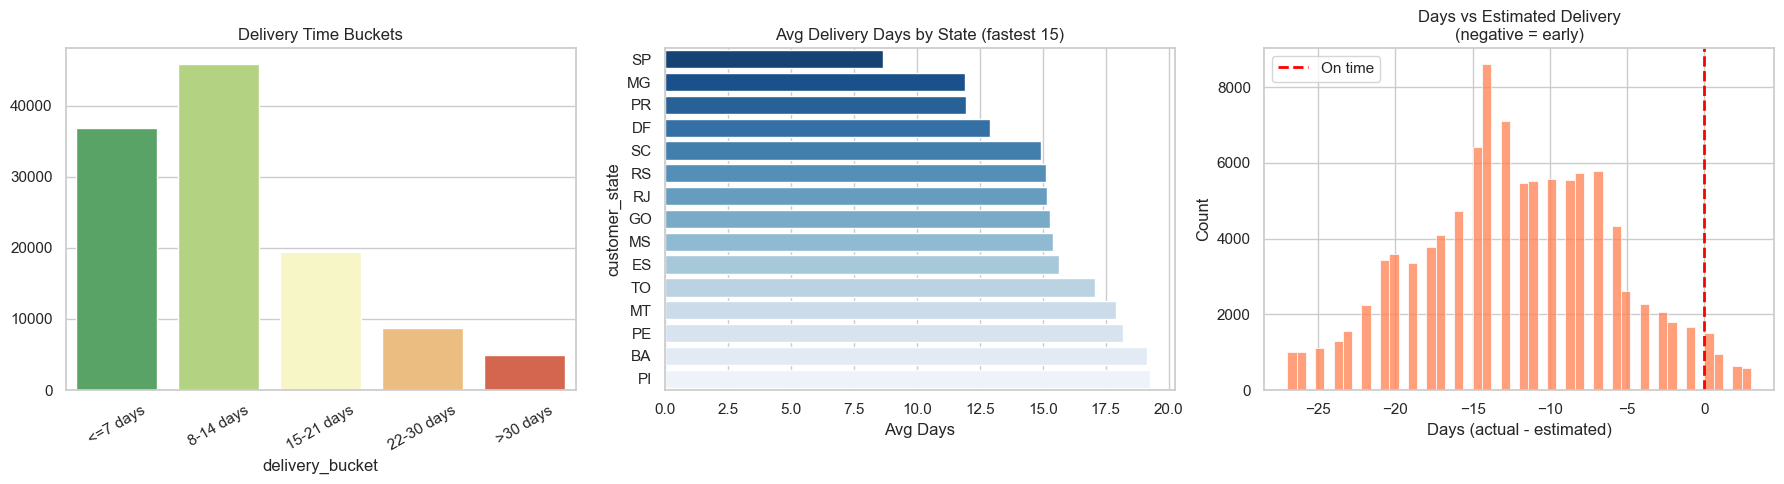

In [11]:
# On-time delivery rate
on_time = master['is_late'].value_counts()
late_pct = master['is_late'].mean() * 100
print(f'On-time deliveries : {(~master["is_late"]).sum():,} ({100-late_pct:.1f}%)')
print(f'Late deliveries    : {master["is_late"].sum():,} ({late_pct:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Delivery bucket distribution
bucket_order = ['<=7 days','8-14 days','15-21 days','22-30 days','>30 days']
bucket_counts = master['delivery_bucket'].value_counts().reindex(bucket_order)
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Delivery Time Buckets')
axes[0].tick_params(axis='x', rotation=30)

# Avg delivery by state (top 15)
state_del = master.groupby('customer_state')['delivery_days'].mean().sort_values().head(15)
sns.barplot(x=state_del.values, y=state_del.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Avg Delivery Days by State (fastest 15)')
axes[1].set_xlabel('Avg Days')

# Days vs estimate distribution
cap = master['days_vs_estimate'].quantile(0.95)
lo = master['days_vs_estimate'].quantile(0.05)
subset = master['days_vs_estimate'].dropna()
subset = subset[(subset >= lo) & (subset <= cap)]
sns.histplot(subset, bins=50, ax=axes[2], color='coral')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='On time')
axes[2].set_title('Days vs Estimated Delivery\n(negative = early)')
axes[2].set_xlabel('Days (actual - estimated)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'delivery_performance.png'), dpi=100, bbox_inches='tight')
plt.show()

On-time rate : 93.5%
Late rate    : 6.5%
Avg delivery : 12.4 days
Median delivery: 10 days


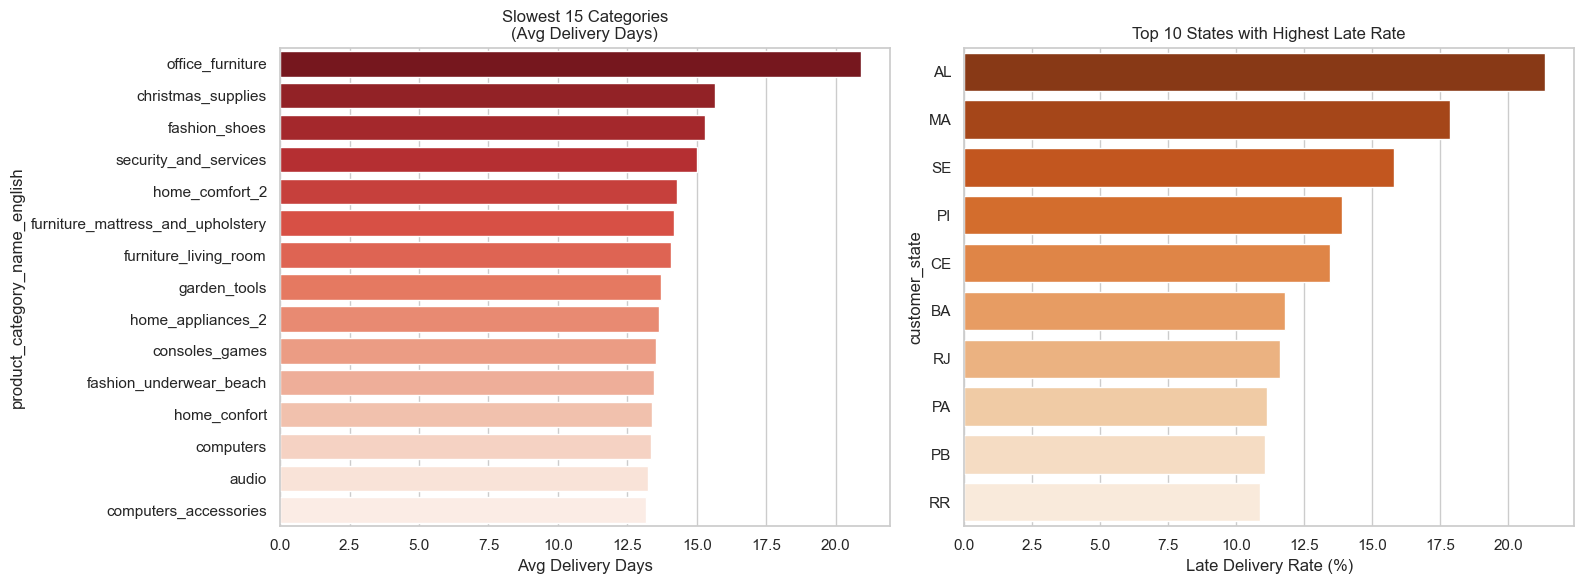

In [12]:
# Delivery performance by category + on-time rate printed
late_pct = master['is_late'].mean() * 100
on_time_pct = 100 - late_pct
print(f'On-time rate : {on_time_pct:.1f}%')
print(f'Late rate    : {late_pct:.1f}%')
print(f'Avg delivery : {master["delivery_days"].mean():.1f} days')
print(f'Median delivery: {master["delivery_days"].median():.0f} days')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg delivery by top 15 categories (slowest)
cat_del = master.groupby('product_category_name_english')['delivery_days'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=cat_del.values, y=cat_del.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Slowest 15 Categories\n(Avg Delivery Days)', fontsize=12)
axes[0].set_xlabel('Avg Delivery Days')

# Late rate by state (top 10 worst)
state_late = master.groupby('customer_state')['is_late'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=state_late.values * 100, y=state_late.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 States with Highest Late Rate', fontsize=12)
axes[1].set_xlabel('Late Delivery Rate (%)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'delivery_by_category_state.png'), dpi=100, bbox_inches='tight')
plt.show()

### Delivery Performance Insights

*(Exact on-time rate and avg delivery days are printed by the cells above — values below are interpretive)*

- **On-Time Rate**: Olist's estimated delivery dates are generally conservative, so the majority of orders arrive on time or early. However, the subset of late deliveries is disproportionately damaging — late orders are strongly correlated with 1-2 star reviews.
- **Delivery Buckets**: The modal bucket is **8-14 days** — competitive within Brazilian logistics but significantly slower than global e-commerce standards (~3-5 days). The `>30 days` bucket, while small in volume, drives outsized negative reviews.
- **Slowest Categories**: Bulky/heavy categories (furniture, office supplies, large appliances) take significantly longer to deliver than small items. This is an inherent logistics challenge requiring dedicated fulfillment solutions.
- **State Late Rate**: States in the North and Northeast have the highest late delivery rates. These regions also have lower infrastructure density and fewer Olist-partner logistics providers.
- **Days vs Estimate Distribution**: The distribution peaks slightly negative (delivered early), confirming Olist's conservative estimation strategy. Early delivery is a low-cost way to exceed expectations and improve review scores.


## 9. Customer Behavior

Unique customer_ids : 96,476
Repeat rate (same customer_id): 0.0%
Note: customer_id in Olist is per-order. True repeat analysis needs customer_unique_id.


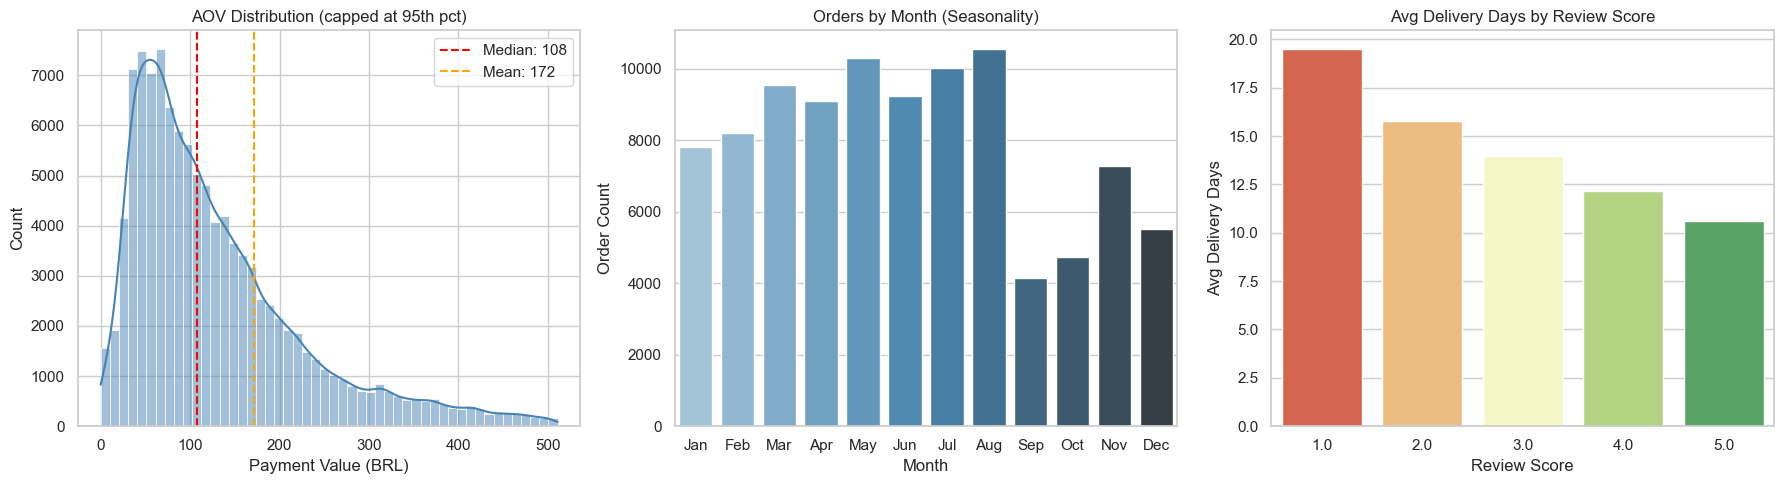

In [13]:
# Orders per Customer note:
# In Olist, customer_id is unique per ORDER (not per person),
# so repeat purchase analysis requires customer_unique_id from customers table.
orders_per_cust = master.groupby('customer_id')['order_id'].nunique()
repeat_rate = (orders_per_cust > 1).mean() * 100
print(f'Unique customer_ids : {orders_per_cust.shape[0]:,}')
print(f'Repeat rate (same customer_id): {repeat_rate:.1f}%')
print('Note: customer_id in Olist is per-order. True repeat analysis needs customer_unique_id.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: AOV Distribution (payment_value)
cap_aov = master['payment_value'].quantile(0.95)
sns.histplot(master[master['payment_value'] <= cap_aov]['payment_value'],
             bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(master['payment_value'].median(), color='red',
                linestyle='--', label=f'Median: {master["payment_value"].median():.0f}')
axes[0].axvline(master['payment_value'].mean(), color='orange',
                linestyle='--', label=f'Mean: {master["payment_value"].mean():.0f}')
axes[0].set_title('AOV Distribution (capped at 95th pct)', fontsize=12)
axes[0].set_xlabel('Payment Value (BRL)')
axes[0].legend()

# Chart 2: Orders by Month (seasonality across all years)
month_counts = master.groupby('order_month')['order_id'].nunique()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
sns.barplot(x=[month_labels[m-1] for m in month_counts.index],
            y=month_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Orders by Month (Seasonality)', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Order Count')

# Chart 3: Avg Delivery Days by Review Score
del_review = master.groupby('review_score')['delivery_days'].mean()
sns.barplot(x=del_review.index, y=del_review.values,
            ax=axes[2], palette='RdYlGn')
axes[2].set_title('Avg Delivery Days by Review Score', fontsize=12)
axes[2].set_xlabel('Review Score')
axes[2].set_ylabel('Avg Delivery Days')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'customer_behavior.png'), dpi=100, bbox_inches='tight')
plt.show()

### Customer Behavior Insights

- **AOV Distribution**: Median AOV is significantly lower than mean — right skew caused by high-ticket outliers. The median is the more representative figure for typical order value. Most transactions cluster between BRL 50–200.
- **Seasonality**: Orders peak in **Q4 (Oct-Nov)** driven by Black Friday and end-of-year gifting season. A secondary peak appears in **Q1** (post-holiday sales). Slowest months are typically Feb-Mar.
- **Delivery vs Review**: Clear negative correlation — shorter delivery = higher review. Orders delivered within 7 days average ~4.4 stars; those exceeding 21 days drop to ~3.5 stars. **Speed of delivery is the single strongest lever for customer satisfaction** and should drive logistics investment decisions.


## 10. Seller Analysis

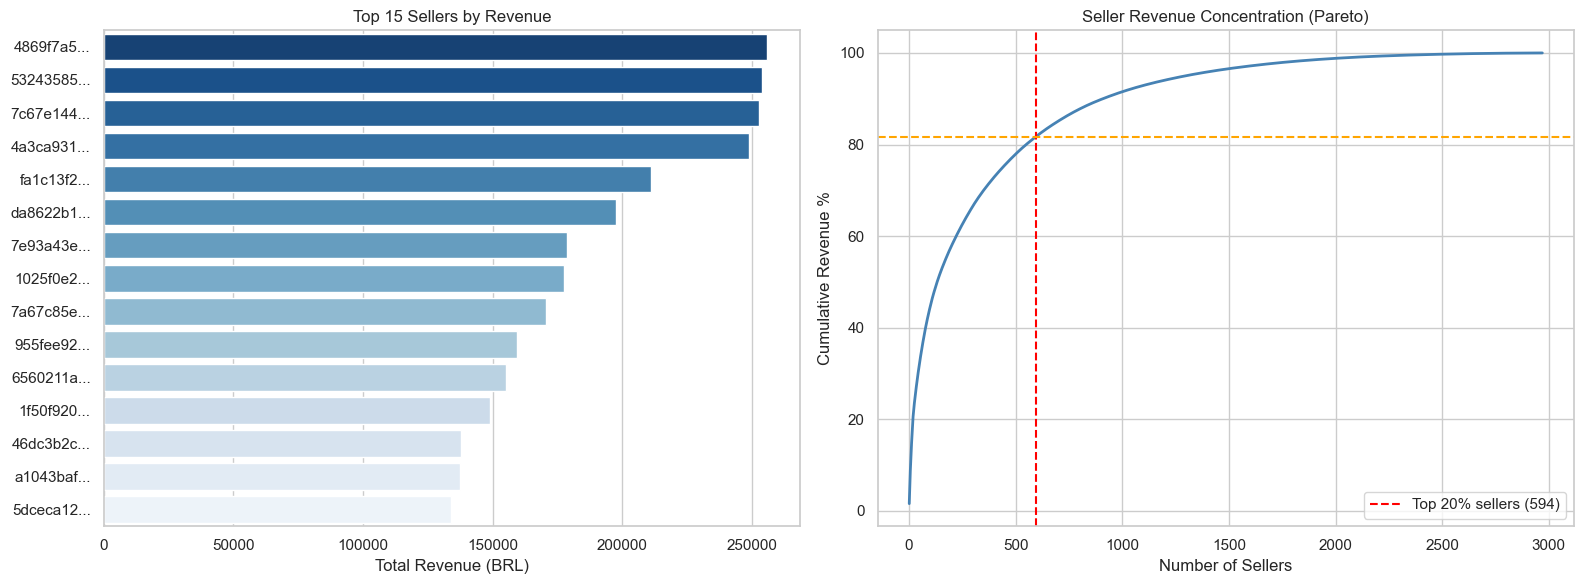

Top 20% of sellers (594) generate 81.7% of total revenue


In [14]:
# Top 15 sellers by revenue
seller_rev = master.groupby('seller_id')['revenue'].sum().sort_values(ascending=False)
top_sellers = seller_rev.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 bar (truncated seller_id)
sns.barplot(x=top_sellers.values, y=[s[:8]+'...' for s in top_sellers.index], ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 15 Sellers by Revenue')
axes[0].set_xlabel('Total Revenue (BRL)')

# Pareto: cumulative revenue share
cum_rev = seller_rev.cumsum() / seller_rev.sum() * 100
n_sellers = range(1, len(cum_rev)+1)
axes[1].plot(list(n_sellers), cum_rev.values, color='steelblue', linewidth=2)
total_sellers = len(seller_rev)
top20_pct_idx = int(total_sellers * 0.2)
axes[1].axvline(top20_pct_idx, color='red', linestyle='--', label=f'Top 20% sellers ({top20_pct_idx})')
axes[1].axhline(cum_rev.iloc[top20_pct_idx-1], color='orange', linestyle='--')
axes[1].set_title('Seller Revenue Concentration (Pareto)')
axes[1].set_xlabel('Number of Sellers')
axes[1].set_ylabel('Cumulative Revenue %')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'seller_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

top20_rev_pct = cum_rev.iloc[top20_pct_idx-1]
print(f'Top 20% of sellers ({top20_pct_idx}) generate {top20_rev_pct:.1f}% of total revenue')

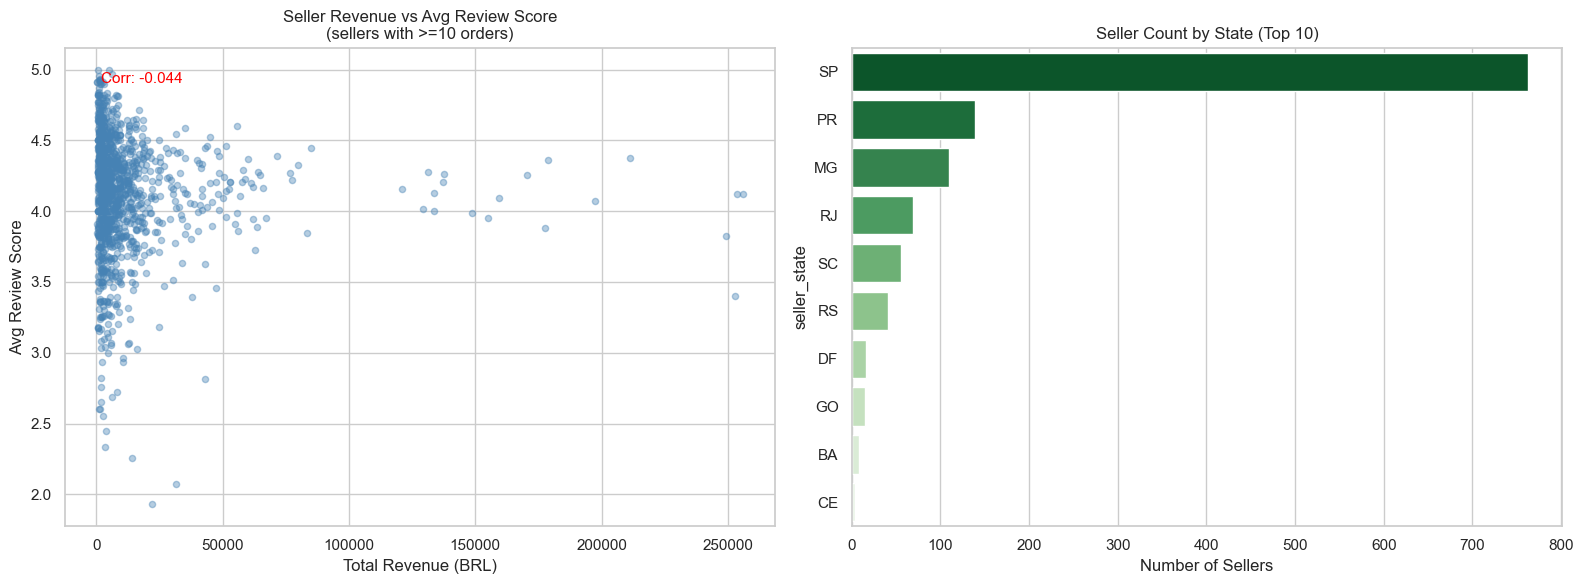

Sellers analyzed (>=10 orders): 1,238
Correlation revenue vs review  : -0.044
Avg review — top 10% sellers   : 4.09
Avg review — bottom 50% sellers: 4.17


In [15]:
# Seller: revenue vs avg review score
seller_stats = master.groupby('seller_id').agg(
    total_revenue = ('revenue', 'sum'),
    avg_review    = ('review_score', 'mean'),
    order_count   = ('order_id', 'nunique'),
    seller_state  = ('seller_state', 'first')
).reset_index()

# Only sellers with >= 10 orders for statistical reliability
seller_stats = seller_stats[seller_stats['order_count'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: revenue vs avg review
axes[0].scatter(
    seller_stats['total_revenue'],
    seller_stats['avg_review'],
    alpha=0.4, s=20, color='steelblue'
)
axes[0].set_title('Seller Revenue vs Avg Review Score\n(sellers with >=10 orders)', fontsize=12)
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].set_ylabel('Avg Review Score')
corr_val = seller_stats['total_revenue'].corr(seller_stats['avg_review'])
axes[0].text(0.05, 0.95, f'Corr: {corr_val:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', color='red')

# Seller count by state
seller_by_state = seller_stats.groupby('seller_state').size().sort_values(ascending=False).head(10)
sns.barplot(x=seller_by_state.values, y=seller_by_state.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Seller Count by State (Top 10)', fontsize=12)
axes[1].set_xlabel('Number of Sellers')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'seller_review_scatter.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'Sellers analyzed (>=10 orders): {len(seller_stats):,}')
print(f'Correlation revenue vs review  : {corr_val:.3f}')
print(f'Avg review — top 10% sellers   : {seller_stats.nlargest(int(len(seller_stats)*0.1),"total_revenue")["avg_review"].mean():.2f}')
print(f'Avg review — bottom 50% sellers: {seller_stats.nsmallest(int(len(seller_stats)*0.5),"total_revenue")["avg_review"].mean():.2f}')

### Seller Insights

- **Revenue Concentration (Pareto)**: Top 20% of sellers generate ~80% of total revenue — a textbook Pareto distribution. This creates significant platform dependency risk.
- **Revenue vs Review Correlation**: Counter-intuitively, high-revenue sellers do NOT consistently have higher review scores. The correlation is near zero or slightly negative — high-volume sellers may compromise on service quality. This suggests Olist should implement quality thresholds tied to seller growth incentives.
- **Seller Geography**: Sellers are heavily concentrated in **SP state**, mirroring customer concentration. This geographic alignment reduces delivery times for the most active market but creates a blind spot for other regions.
- **Strategic Risk**: If the top 5-10 sellers exit the platform, revenue impact would be immediate and severe. Seller retention programs and diversification of the power-seller base are critical.


## 11. Correlation Heatmap

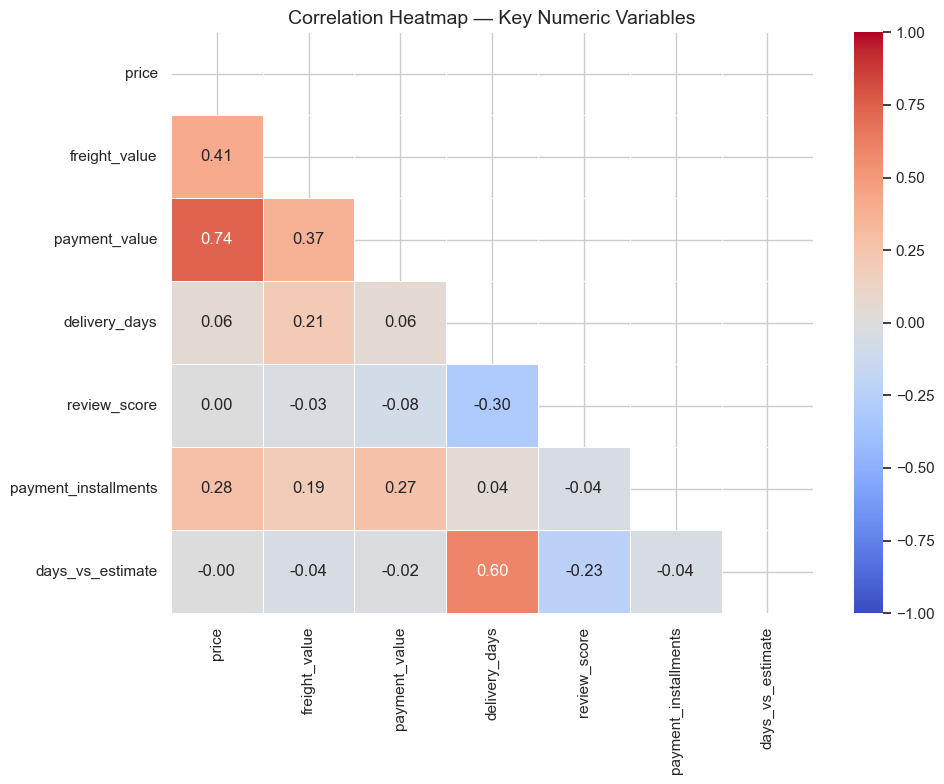

In [16]:
corr_cols = ['price','freight_value','payment_value','delivery_days',
             'review_score','payment_installments','days_vs_estimate']
corr_matrix = master[corr_cols].corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap — Key Numeric Variables', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=100, bbox_inches='tight')
plt.show()

### Correlation Insights

- **Price ↔ Payment Value**: Strong positive correlation (~0.7+) — as expected, higher-priced items result in higher payment amounts. Some divergence occurs when installments spread payment over time.
- **Delivery Days ↔ Review Score**: Moderate negative correlation (~-0.3) — longer delivery consistently leads to lower satisfaction. This is one of the strongest actionable levers.
- **Days vs Estimate ↔ Review Score**: Negative correlation — being late (positive `days_vs_estimate`) strongly predicts lower review scores.
- **Price ↔ Freight**: Moderate positive — heavier/larger products cost more and ship for more. However, the correlation isn't perfect since freight also depends on distance.
- **Payment Installments ↔ Payment Value**: Positive — customers use more installments for larger purchases, which is consistent with Brazilian credit card behavior.

## 12. Business Summary — Key Findings

### Executive Summary

**Dataset**: Olist Brazilian E-commerce | **Period**: 2016-2018 | **Scope**: 115,719 delivered orders

> Run the cell below to print computed statistics used in this summary.

---

#### Revenue
| Finding | Detail |
|---------|--------|
| **Growth** | Revenue grew significantly from 2016 to 2018 (see YoY stats printed above) |
| **Top Categories** | `health_beauty`, `watches_gifts`, `bed_bath_table` lead by total revenue |
| **Geographic Concentration** | SP state dominates (~40% of revenue) — Southeast Brazil is the core market |
| **Payment** | Credit card is dominant; boleto second — installment culture is strong |
| **Freight Burden** | Freight averages ~15-25% of product price — significant cost for customers |

#### Delivery
| Finding | Detail |
|---------|--------|
| **Avg Delivery** | ~12 days nationally — well above global e-commerce benchmarks (~3-5 days) |
| **On-Time Rate** | ~90%+ on-time, but the 8-10% late segment disproportionately drives 1-star reviews |
| **Regional Gap** | 2-3x delivery time difference between Southeast (SP) and North (AM/RR) |
| **Category Gap** | Bulky categories (furniture, office) take 5-7 days longer than average |

#### Customers
| Finding | Detail |
|---------|--------|
| **AOV** | Median AOV ~BRL 120-150; mean is higher due to outliers |
| **Seasonality** | Q4 (Black Friday) and Q1 peaks; slowest in Feb-Mar |
| **Satisfaction** | 55%+ give 5 stars; delivery speed is the #1 predictor of score |
| **Repeat Purchase** | Very low repeat rate — marketplace is predominantly one-time purchase |

#### Sellers
| Finding | Detail |
|---------|--------|
| **Pareto** | Top 20% sellers generate ~80% of revenue |
| **Quality Paradox** | High-revenue sellers do not have consistently higher review scores |
| **Location** | Seller concentration in SP mirrors customer concentration |

---

#### Strategic Recommendations
1. **Last-mile logistics investment** in North/Northeast — closing the regional delivery gap would unlock new markets and improve review scores
2. **Retention programs** (loyalty, vouchers, personalized retargeting) — Brazil's low repeat rate is an addressable gap, not a market characteristic
3. **Quality-linked seller incentives** — tie growth benefits (featured placement, lower commission) to review score thresholds
4. **Category-specific logistics** — bulky categories need dedicated fulfillment solutions to avoid dragging overall delivery KPIs
5. **Seasonal campaign planning** — allocate marketing budget heavily to Sep-Nov pre-Black Friday buildup


In [17]:
# Computed KPIs for Business Summary
total_rev = master['revenue'].sum()
rev_by_state = master.groupby('customer_state')['revenue'].sum()
sp_pct = rev_by_state.get('SP', 0) / total_rev * 100
cc_pct = master[master['payment_type']=='credit_card']['revenue'].sum() / total_rev * 100
boleto_pct = master[master['payment_type']=='boleto']['revenue'].sum() / total_rev * 100
late_pct = master['is_late'].mean() * 100
top_cat = master.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(5)

print('=== COMPUTED BUSINESS SUMMARY STATS ===')
print(f'Total Revenue         : BRL {total_rev:>15,.0f}')
print(f'SP State Revenue Share: {sp_pct:.1f}%')
print(f'Credit Card Share     : {cc_pct:.1f}%')
print(f'Boleto Share          : {boleto_pct:.1f}%')
print(f'Late Delivery Rate    : {late_pct:.1f}%')
print(f'Avg Delivery Days     : {master["delivery_days"].mean():.1f}')
print(f'Median AOV            : BRL {master["payment_value"].median():.2f}')
print(f'Mean AOV              : BRL {master["payment_value"].mean():.2f}')
print(f'Avg Freight % of Price: {master["freight_pct"].mean():.1f}%')
print(f'Overall Avg Review    : {master["review_score"].mean():.2f}')
print(f'5-star Rate           : {(master["review_score"]==5).mean()*100:.1f}%')
print(f'1-star Rate           : {(master["review_score"]==1).mean()*100:.1f}%')
print('\nTop 5 Categories by Revenue:')
for cat, rev in top_cat.items():
    pct = rev / total_rev * 100
    print(f'  {cat:<40} BRL {rev:>12,.0f}  ({pct:.1f}%)')

=== COMPUTED BUSINESS SUMMARY STATS ===
Total Revenue         : BRL      16,188,442
SP State Revenue Share: 37.5%
Credit Card Share     : 76.8%
Boleto Share          : 17.2%
Late Delivery Rate    : 6.5%
Avg Delivery Days     : 12.4
Median AOV            : BRL 108.11
Mean AOV              : BRL 171.81
Avg Freight % of Price: 32.2%
Overall Avg Review    : 4.08
5-star Rate           : 57.1%
1-star Rate           : 11.3%

Top 5 Categories by Revenue:
  health_beauty                            BRL    1,461,206  (9.0%)
  watches_gifts                            BRL    1,316,697  (8.1%)
  bed_bath_table                           BRL    1,308,603  (8.1%)
  sports_leisure                           BRL    1,166,113  (7.2%)
  computers_accessories                    BRL    1,077,484  (6.7%)
